In [4]:
import os
import sys
from tqdm import tqdm
import numpy as np
import pandas as pd


In [5]:
!ls ../../../../scratch/train/logs

MOBILENET_V2_AP_ROI		     TRAIN_MOBILE_V2_AP_ROI
MOBILENET_V3_AP_ROI		     TRAIN_MOBILE_V2_BS4
MOBILENET_V4_AP_ROI		     TRAIN_MOBILE_V2_BS8
MOBILENET_V5_AP_ROI		     TRAIN_MOBILE_V3
TRAIN_MOBILENET_V1_AP_ROI_250_BS32_  TRAIN_MOBILE_V3_AP
TRAIN_MOBILENET_V2_AP_ROI	     TRAIN_MOBILE_V3_AP_ROI
TRAIN_MOBILENET_V3_AP_ROI	     TRAIN_MOBILE_V3_BS4
TRAIN_MOBILENET_V4_AP_ROI	     TRAIN_MOBILE_V3_BS8
TRAIN_MOBILENET_V5_AP_ROI	     TRAIN_MOBILE_V4
TRAIN_MOBILE_V1			     TRAIN_MOBILE_V4_AP
TRAIN_MOBILE_V1_AP		     TRAIN_MOBILE_V4_AP_ROI
TRAIN_MOBILE_V1_AP_ROI		     TRAIN_MOBILE_V4_BS4
TRAIN_MOBILE_V1_BS4		     TRAIN_MOBILE_V4_BS8
TRAIN_MOBILE_V1_BS8		     TRAIN_MOBILE_V5
TRAIN_MOBILE_V1_ER1		     TRAIN_MOBILE_V5_AP
TRAIN_MOBILE_V1_ER10		     TRAIN_MOBILE_V5_AP_ROI
TRAIN_MOBILE_V1_ER2		     TRAIN_MOBILE_V5_BS4
TRAIN_MOBILE_V1_ER3		     TRAIN_OG
TRAIN_MOBILE_V1_ER8		     TRAIN_OG_AP
TRAIN_MOBILE_V1_ER9		     TRAIN_OG_AP_ROI
TRAIN_MOBILE_V1_ROI		     TRAIN_OG_AP_ROI_E250
TRAIN_MOBILE_V2			     TRAIN

In [6]:
import subprocess

# Define your parameter values
experiments = [
               "TRAIN_OG_AP",
               "TRAIN_MOBILE_V1_AP",
               "TRAIN_MOBILE_V2_AP",
               "TRAIN_MOBILE_V3_AP",
               "TRAIN_MOBILE_V4_AP",
               "TRAIN_MOBILE_V5_AP",
               ]
epochs = 10
# model = ["densenet_og",
#          "mobilenet_v1",
#          "mobilenet_v2",
#          "mobilenet_v3",
#          "mobilenet_v4",
#          "mobilenet_v5"]

exp_model_dict = {}

for exp in experiments:
    split_exp_name = exp.split("_")
    if "OG" in split_exp_name[1]:
        exp_model_dict[exp] = "densenet_og_ap"
    elif "MOBILE" in split_exp_name[:2] or "MOBILENET" in split_exp_name[:2]:
        if "V1" in split_exp_name[2]:
            exp_model_dict[exp] = "mobilenet_v1_ap"
        if "V2" in split_exp_name[2]:
            exp_model_dict[exp] = "mobilenet_v2_ap"
        if "V3" in split_exp_name[2]:
            exp_model_dict[exp] = "mobilenet_v3_ap"
        if "V4" in split_exp_name[2]:
            exp_model_dict[exp] = "mobilenet_v4_ap"
        if "V5" in split_exp_name[2]:
            exp_model_dict[exp] = "mobilenet_v5_ap"
    else:
        print(f"Experiment {exp} does not follow our current naming structure!")
        exit(1)

dataset_path = "../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/'openEDS Dataset'/openEDS/openEDS/"

# dataset_path = "../../autoROI_imgs"

# Loop over experiments and batch sizes
for exp in experiments:
    statement = exp.split("_")[-1]
    if "BS" in statement:
        bs = int(statement[2:])
        er = 6
    elif "ER" in statement:
        er = int(statement[2:])
        bs = 8
    else:
        # defaults
        er = 6
        bs = 8
    
    # Construct the terminal command using f-string formatting.
    # cmd = f"python train.py --model {exp_model_dict[exp]} --expname {exp} --bs {bs} --epochs {epochs} --useGPU True --dataset {dataset_path} --er {er}"
    # weights_list = os.listdir(os.path.join(os.getcwd(), f"../models/weights/logs/{exp}/models/"))

    weights_list = os.listdir(os.path.join(os.getcwd(), f"../../../../scratch/train/logs/{exp}/models"))



    # print(weights_list)
    weight = weights_list[-1]
    if weight == "dense_net_0.pkl":
        weight = weights_list[-2]
    # cmd = f" python ../test.py --model {exp_model_dict[exp]} --load ../models/weights/logs/{exp}/models/{weight} --bs {bs} --dataset {dataset_path} --expname {exp[6:]} --er {er} --testsavedir /home/hice1/snachimuthu7/scratch/test"
    cmd = f" python ../test.py --model {exp_model_dict[exp]} --load {os.path.join(os.getcwd(), f'../../../../scratch/train/logs/{exp}/models')}/{weight} --bs {bs} --dataset {dataset_path} --expname {exp[6:]} --er {er} --testsavedir /home/hice1/snachimuthu7/scratch/test"
    print("Running command:", cmd)
    # Run the command; you can set shell=True to run the command as a string.
    # result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    # # Optionally, print standard output and error:
    # print("Output:\n", result.stdout)
    # if result.stderr:
    #     print("Error:\n", result.stderr)
    os.system(cmd)

Running command:  python ../test.py --model densenet_og_ap --load /home/hice1/snachimuthu7/BMED6780/VisualTracking/scripts/playground/../../../../scratch/train/logs/TRAIN_OG_AP/models/TRAIN_OG_AP0.pkl --bs 8 --dataset ../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/'openEDS Dataset'/openEDS/openEDS/ --expname OG_AP --er 6 --testsavedir /home/hice1/snachimuthu7/scratch/test
'parsed input parameters:'
{'bs': 8,
 'dataset': '../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/openEDS '
            'Dataset/openEDS/openEDS/',
 'device': None,
 'epochs': 250,
 'er': 6,
 'evalsplit': 'val',
 'expname': 'OG_AP',
 'load': '/home/hice1/snachimuthu7/BMED6780/VisualTracking/scripts/playground/../../../../scratch/train/logs/TRAIN_OG_AP/models/TRAIN_OG_AP0.pkl',
 'lr': 0.001,
 'model': 'densenet_og_ap',
 'resume': False,
 'save': '0try',
 'savemodel': False,
 'seed': 1111,
 'test': False,
 'testrun': False,
 'testsavedir': '/home/hice1/snachimuthu7/scratch/test',
 'useGPU': 

100%|██████████| 343/343 [02:23<00:00,  2.39it/s]


Total Testing Time before mIoU calculation: 2.9089377403259276
per-class mIoU:     [0.97010502 0.6268688  0.86447466 0.93441142]
per-class precision: [0.97381513 0.96848671 0.98997933 0.99949703]
per-class recall:    [0.97402286 0.96940877 0.98983055 0.9994982 ]
per-class f1:        [0.97389815 0.9688614  0.9898928  0.99949757]
Total calculation time taken: 26.06527465581894 min
Running command:  python ../test.py --model mobilenet_v1_ap --load /home/hice1/snachimuthu7/BMED6780/VisualTracking/scripts/playground/../../../../scratch/train/logs/TRAIN_MOBILE_V1_AP/models/TRAIN_MOBILE_V1_AP5.pkl --bs 8 --dataset ../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/'openEDS Dataset'/openEDS/openEDS/ --expname MOBILE_V1_AP --er 6 --testsavedir /home/hice1/snachimuthu7/scratch/test
'parsed input parameters:'
{'bs': 8,
 'dataset': '../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/openEDS '
            'Dataset/openEDS/openEDS/',
 'device': None,
 'epochs': 250,
 'er': 6,
 

100%|██████████| 343/343 [02:29<00:00,  2.30it/s]


Total Testing Time before mIoU calculation: 3.0012100100517274
per-class mIoU:     [0.99541535 0.94086333 0.97884314 0.97435314]
per-class precision: [0.996075   0.99578056 0.99852427 0.99980757]
per-class recall:    [0.99607447 0.99578757 0.99852138 0.99980637]
per-class f1:        [0.99607473 0.99578379 0.9985226  0.99980681]
Total calculation time taken: 26.025634610652922 min
Running command:  python ../test.py --model mobilenet_v2_ap --load /home/hice1/snachimuthu7/BMED6780/VisualTracking/scripts/playground/../../../../scratch/train/logs/TRAIN_MOBILE_V2_AP/models/TRAIN_MOBILE_V2_AP1.pkl --bs 8 --dataset ../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/'openEDS Dataset'/openEDS/openEDS/ --expname MOBILE_V2_AP --er 6 --testsavedir /home/hice1/snachimuthu7/scratch/test
'parsed input parameters:'
{'bs': 8,
 'dataset': '../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/openEDS '
            'Dataset/openEDS/openEDS/',
 'device': None,
 'epochs': 250,
 'er': 6,


...

Total Testing Time before mIoU calculation: 2.9246300061543784
per-class mIoU:     [0.99464556 0.93059977 0.97296763 0.97503897]
per-class precision: [0.99543382 0.99502033 0.99811372 0.99981264]
per-class recall:    [0.99541621 0.99501414 0.99809614 0.99981309]
per-class f1:        [0.99542292 0.99501712 0.99810185 0.99981279]
Total calculation time taken: 26.085606733957928 min
Running command:  python ../test.py --model mobilenet_v4_ap --load /home/hice1/snachimuthu7/BMED6780/VisualTracking/scripts/playground/../../../../scratch/train/logs/TRAIN_MOBILE_V4_AP/models/TRAIN_MOBILE_V4_AP9.pkl --bs 8 --dataset ../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/'openEDS Dataset'/openEDS/openEDS/ --expname MOBILE_V4_AP --er 6 --testsavedir /home/hice1/snachimuthu7/scratch/test
'parsed input parameters:'
{'bs': 8,
 'dataset': '../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/openEDS '
            'Dataset/openEDS/openEDS/',
 'device': None,
 'epochs': 250,
 'er': 6,


100%|██████████| 343/343 [02:23<00:00,  2.39it/s]


Total Testing Time before mIoU calculation: 2.909741481145223
per-class mIoU:     [0.99640377 0.95384506 0.98319775 0.98046015]
per-class precision: [0.99691934 0.99672852 0.99883051 0.99985361]
per-class recall:    [0.99692167 0.99673283 0.99883119 0.99985361]
per-class f1:        [0.99692031 0.99673051 0.99883081 0.99985361]
Total calculation time taken: 25.97646677494049 min
Running command:  python ../test.py --model mobilenet_v5_ap --load /home/hice1/snachimuthu7/BMED6780/VisualTracking/scripts/playground/../../../../scratch/train/logs/TRAIN_MOBILE_V5_AP/models/TRAIN_MOBILE_V5_AP9.pkl --bs 8 --dataset ../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/'openEDS Dataset'/openEDS/openEDS/ --expname MOBILE_V5_AP --er 6 --testsavedir /home/hice1/snachimuthu7/scratch/test
'parsed input parameters:'
{'bs': 8,
 'dataset': '../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/openEDS '
            'Dataset/openEDS/openEDS/',
 'device': None,
 'epochs': 250,
 'er': 6,
 '

100%|██████████| 343/343 [02:23<00:00,  2.39it/s]


Total Testing Time before mIoU calculation: 2.9051817258199057
per-class mIoU:     [0.99578872 0.94301474 0.97863867 0.97838993]
per-class precision: [0.99638559 0.99595143 0.99851437 0.99983801]
per-class recall:    [0.99639069 0.99597313 0.99851752 0.99983755]
per-class f1:        [0.99638077 0.99595661 0.99851384 0.99983774]
Total calculation time taken: 25.946858553091683 min


In [7]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable


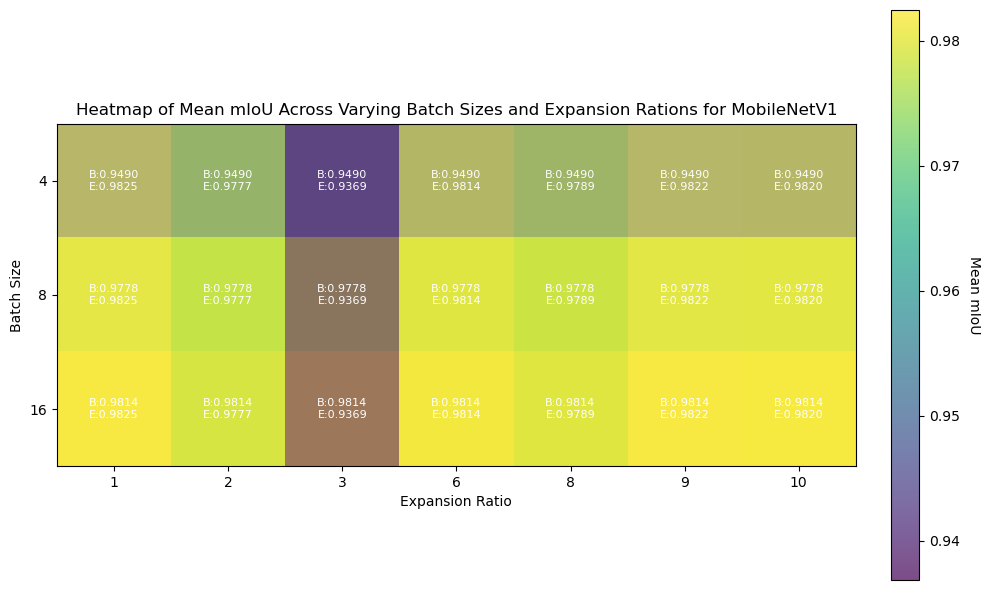

In [8]:
batch_sizes = [4, 8, 16]
expansion_ratios = [1, 2, 3, 6, 8, 9, 10]

bs_mious = [np.mean([0.99171768, 0.89710624, 0.96264515, 0.94462277]), 
            np.mean([0.99595218, 0.94987762, 0.98081396, 0.98464619]), 
            np.mean([0.99681741, 0.95902627, 0.98627608, 0.98360438])]

er_mious = [np.mean([0.99708321, 0.96190401, 0.98611529, 0.98472683]), 
            np.mean([0.99655327, 0.95264667, 0.98171338, 0.97983205]), 
            np.mean([0.98773563, 0.90340062, 0.92222692, 0.93413536]), 
            np.mean([0.99681741, 0.95902627, 0.98627608, 0.98360438]), 
            np.mean([0.99692743, 0.96027832, 0.98094569, 0.97726817]), 
            np.mean([0.99715251, 0.96202885, 0.98568717, 0.98374572]), 
            np.mean([0.99699145, 0.96154063, 0.98480512, 0.9848219])]

df_bs = pd.DataFrame({'Mean mIoU': bs_mious}, index=batch_sizes)

# Create a DataFrame for the Expansion Ratio experiment.
# Since we have only one value per expansion ratio, we can put them in a single row.
df_er = pd.DataFrame([er_mious], columns=expansion_ratios)

grid_bs = np.tile(np.array(bs_mious).reshape(-1, 1), (1, len(expansion_ratios)))
# Replicate er_mious along the rows.
grid_er = np.tile(np.array(er_mious).reshape(1, -1), (len(batch_sizes), 1))

# Define common scale boundaries for color normalization.
vmin = min(np.min(grid_bs), np.min(grid_er))
vmax = max(np.max(grid_bs), np.max(grid_er))

# Create the figure and axis.
fig, ax = plt.subplots(figsize=(10, 6))

# First layer: batch size experiment (lower transparency for better base visibility).
im_bs = ax.imshow(grid_bs, cmap='viridis', alpha=0.7, vmin=vmin, vmax=vmax)
# Second layer: expansion ratio experiment (overlay with higher transparency).
im_er = ax.imshow(grid_er, cmap='viridis', alpha=0.5, vmin=vmin, vmax=vmax)

# Set the tick marks and labels.
ax.set_xticks(np.arange(len(expansion_ratios)))
ax.set_xticklabels(expansion_ratios)
ax.set_yticks(np.arange(len(batch_sizes)))
ax.set_yticklabels(batch_sizes)
ax.set_xlabel("Expansion Ratio")
ax.set_ylabel("Batch Size")
ax.set_title("Heatmap of Mean mIoU Across Varying Batch Sizes and Expansion Rations for MobileNetV1")

# Add a single colorbar for the common mIoU scale.
cbar = fig.colorbar(im_bs, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean mIoU", rotation=270, labelpad=15)

# Annotate each cell with both the BS and ER values.
for i in range(len(batch_sizes)):
    for j in range(len(expansion_ratios)):
        text = f"B:{grid_bs[i, j]:.4f}\nE:{grid_er[i, j]:.4f}"
        ax.text(j, i, text, ha="center", va="center", color="white", fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
np.mean([0.99708832, 0.96289887, 0.98658167, 0.98752444])

0.9835233250000001